In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from matplotlib.ticker import NullLocator
from IPython.display import clear_output, display

if not os.path.exists("path.txt"):
    print("path.txt tidak ditemukan.")
else:
    print("Memuat data dari path.txt")
    with open("path.txt", "r") as f:
        line1 = f.readline().split()
        rows, cols = map(int, line1)

        grid_matrix = []
        for _ in range(rows):
            grid_matrix.append(list(map(int, f.readline().split())))
        grid_array = np.array(grid_matrix)

        line_plen = f.readline().strip()
        path_len = int(line_plen)
        
        path_vertex = []
        for _ in range(path_len):
            line_coord = f.readline().split()
            if not line_coord: break
            r, c = map(int, line_coord)
            path_vertex.append((r, c))

    display_grid = np.zeros((rows, cols, 3))
    for r in range(rows):
        for c in range(cols):
            if grid_array[r][c] == 1:
                display_grid[r][c] = [0.2, 0.2, 0.2]
            else:
                display_grid[r][c] = [1, 1, 1]
                
    print(f"Grid {rows}x{cols} sudah diproses.")

Memuat data dari path.txt
Grid 5000x5000 sudah diproses.


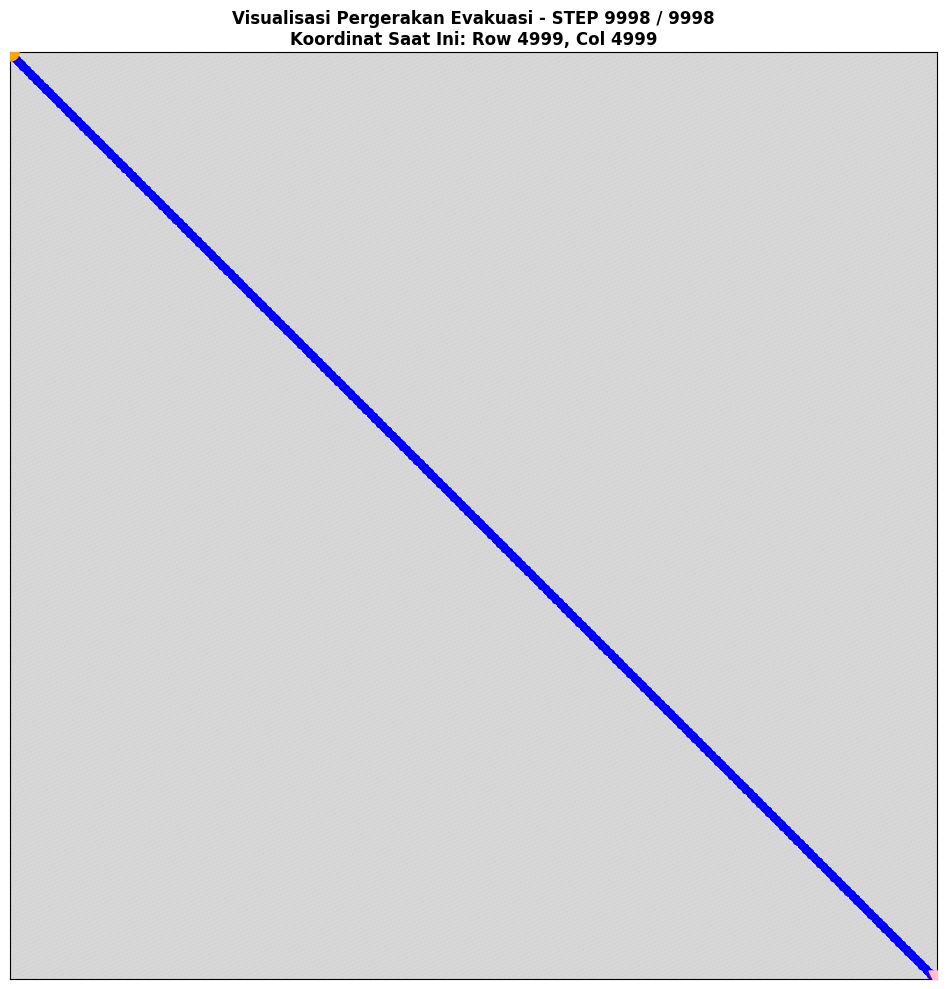

In [3]:
plt.ion()
fig, ax = plt.subplots(figsize=(10, 10))
ANIMATION_STRIDE = 100

for step in range(len(path_vertex)):
    if step != 0 and step != (len(path_vertex) - 1) and (step % ANIMATION_STRIDE != 0):
        continue
        
    ax.clear()

    ax.imshow(display_grid, origin='upper', zorder=1)

    curr_trail = path_vertex[:step+1]
    trail_r = [p[0] for p in curr_trail]
    trail_c = [p[1] for p in curr_trail]

    ax.plot(trail_c, trail_r, color='red', linewidth=3, zorder=2)
    ax.scatter(trail_c, trail_r, color='blue', s=15, zorder=3)

    start_pt = path_vertex[0]
    goal_pt = path_vertex[-1]
    curr_pt = path_vertex[step]

    ax.scatter(start_pt[1], start_pt[0], color='orange', s=150, marker='o', zorder=4)
    ax.scatter(goal_pt[1], goal_pt[0], color='purple', s=150, marker='X', zorder=4)
    ax.scatter(curr_pt[1], curr_pt[0], color='pink', s=150, marker='v', zorder=5)

    ax.set_title(f"Visualisasi Pergerakan Evakuasi - STEP {step} / {path_len-1}\n"
                 f"Koordinat Saat Ini: Row {curr_pt[0]}, Col {curr_pt[1]}", fontsize=12, fontweight='bold')
    
    ax.xaxis.set_major_locator(NullLocator())
    ax.yaxis.set_major_locator(NullLocator())
    
    plt.tight_layout()
    
    clear_output(wait=True)
    display(fig)

    time.sleep(0.01)

plt.ioff()
plt.close(fig)

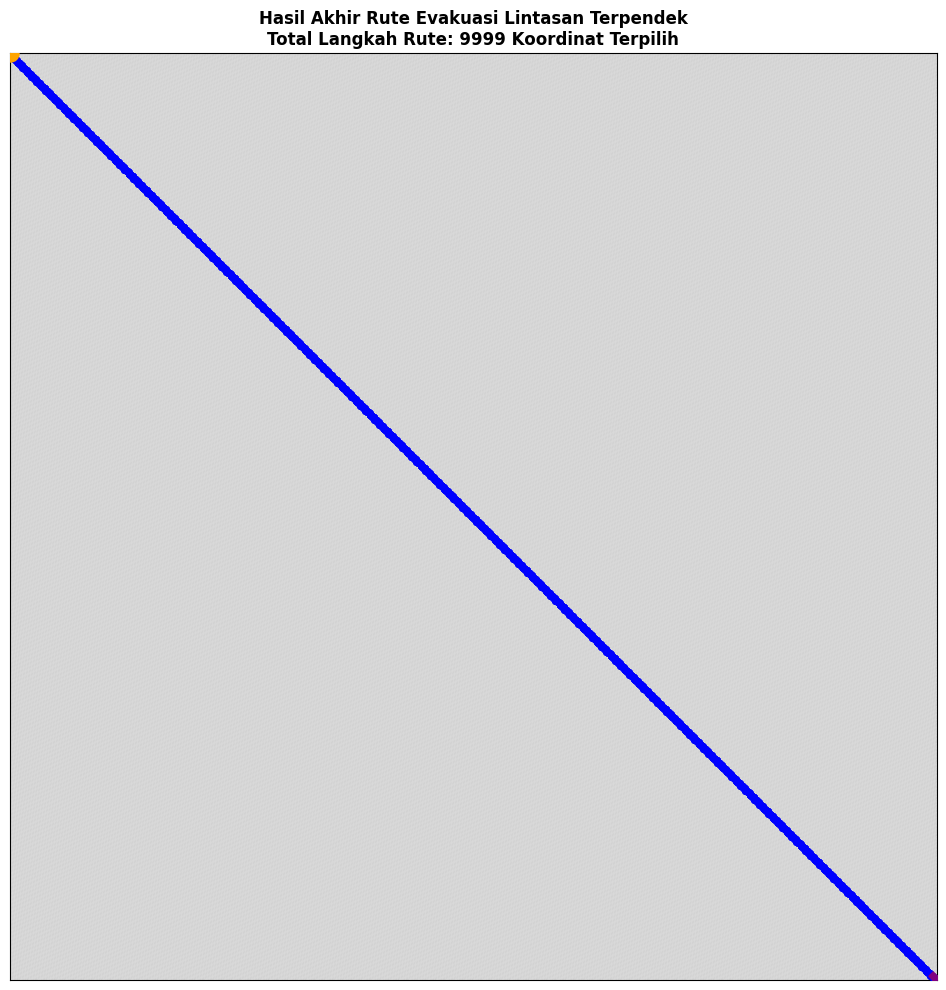

In [4]:
fig_static, ax_static = plt.subplots(figsize=(10, 10))
ax_static.imshow(display_grid, origin='upper', zorder=1)

final_trail_r = [p[0] for p in path_vertex]
final_trail_c = [p[1] for p in path_vertex]

ax_static.plot(final_trail_c, final_trail_r, color='red', linewidth=3, zorder=2)
ax_static.scatter(final_trail_c, final_trail_r, color='blue', s=15, zorder=3)

start_pt = path_vertex[0]
goal_pt = path_vertex[-1]

ax_static.scatter(start_pt[1], start_pt[0], color='orange', s=150, marker='o', zorder=4)
ax_static.scatter(goal_pt[1], goal_pt[0], color='purple', s=150, marker='X', zorder=4)

ax_static.set_title(f"Hasil Akhir Rute Evakuasi Lintasan Terpendek\n"
                    f"Total Langkah Rute: {path_len} Koordinat Terpilih", fontsize=12, fontweight='bold')

ax_static.xaxis.set_major_locator(NullLocator())
ax_static.yaxis.set_major_locator(NullLocator())

plt.tight_layout()
plt.show()

Memuat data dari results.txt


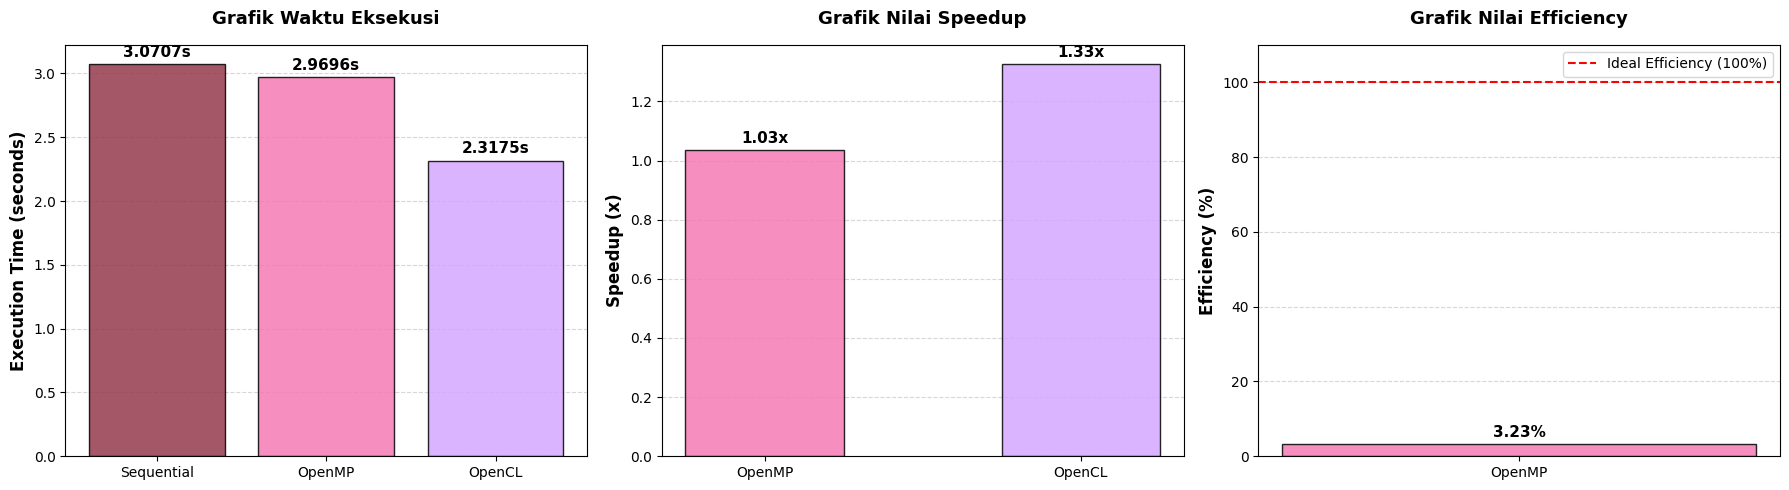

In [5]:
results_path = "results.txt"

if not os.path.exists("results.txt"):
    print("results.txt tidak ditemukan.")
else:
    print("Memuat data dari results.txt")
    with open("results.txt", "r") as f:
        lines = f.readlines()

        seq_time = float(lines[0].strip())
        omp_time = float(lines[1].strip())
        cl_time = float(lines[2].strip())
        speedup_omp = float(lines[3].strip())
        speedup_cl = float(lines[4].strip())
        efficiency_omp = float(lines[5].strip()) * 100
        omp_threads = int(lines[6].strip())

    algorithms = ['Sequential', 'OpenMP', 'OpenCL']
    times = [seq_time, omp_time, cl_time]
    
    speedup_labels = ['OpenMP', 'OpenCL']
    speedups = [speedup_omp, speedup_cl]

    efficiency_labels = ['OpenMP']
    efficiency_values = [efficiency_omp]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    bars1 = ax1.bar(algorithms, times, color=["#943A4C", '#F57AB58C', '#D4A7FFB2'], edgecolor='black', alpha=0.85)
    ax1.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_title('Grafik Waktu Eksekusi', fontsize=13, fontweight='bold', pad=15)
    ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax1.set_axisbelow(True)
    
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.4f}s',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

    bars2 = ax2.bar(speedup_labels, speedups, color=['#F57AB58C', '#D4A7FFB2'], width=0.5, edgecolor='black', alpha=0.85)
    ax2.set_ylabel('Speedup (x)', fontsize=12, fontweight='bold')
    ax2.set_title('Grafik Nilai Speedup', fontsize=13, fontweight='bold', pad=15)
    ax2.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax2.set_axisbelow(True)
    
    for bar in bars2:
        height = bar.get_height()
        ax2.annotate(f'{height:.2f}x',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

    bars3 = ax3.bar(efficiency_labels, efficiency_values, color=['#F57AB58C'], width=0.3, edgecolor='black', alpha=0.85)
    ax3.set_ylabel('Efficiency (%)', fontsize=12, fontweight='bold')
    ax3.set_title('Grafik Nilai Efficiency', fontsize=13, fontweight='bold', pad=15)
    ax3.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax3.set_axisbelow(True)
    
    ax3.set_ylim(0, max(110, max(efficiency_values) + 15))
    ax3.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Ideal Efficiency (100%)')
    ax3.legend(loc='upper right')

    for bar in bars3:
        height = bar.get_height()
        ax3.annotate(f'{height:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

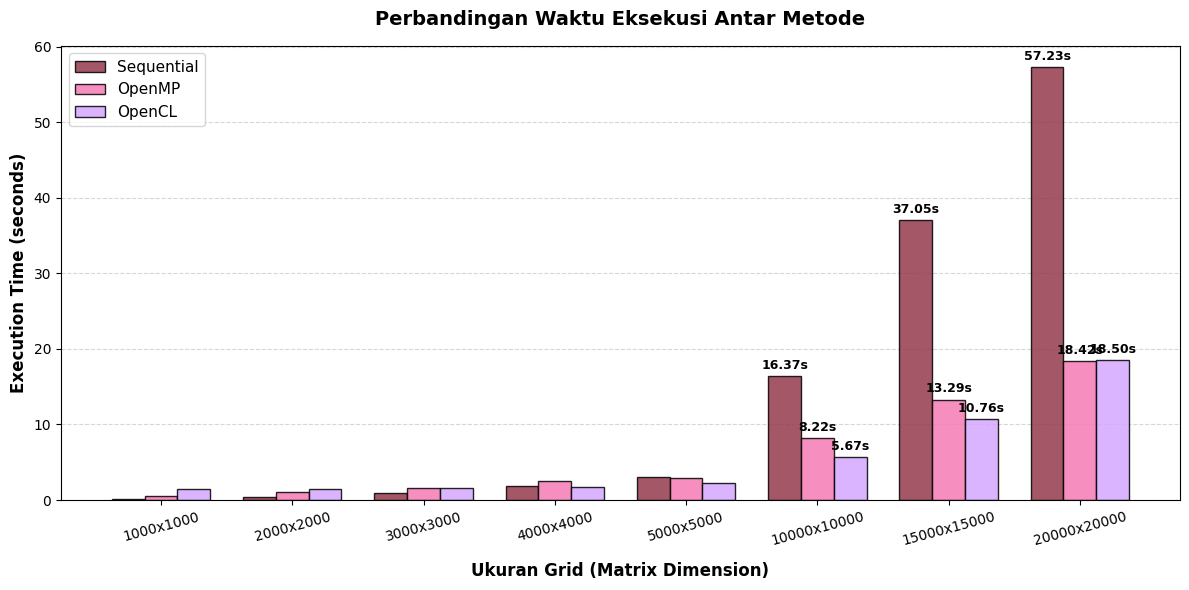

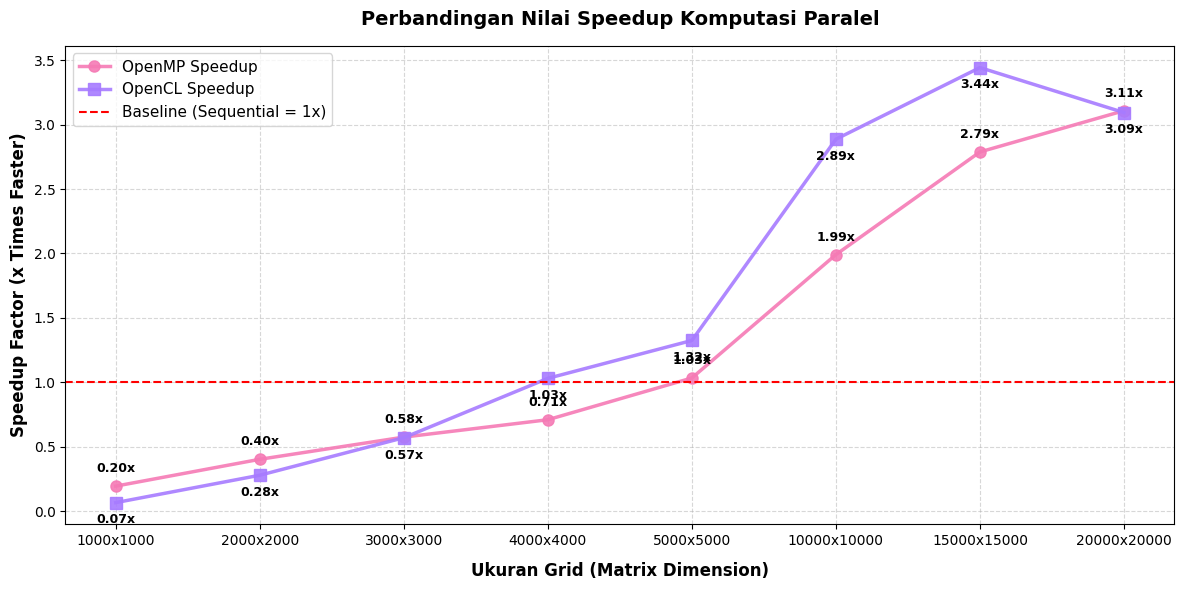

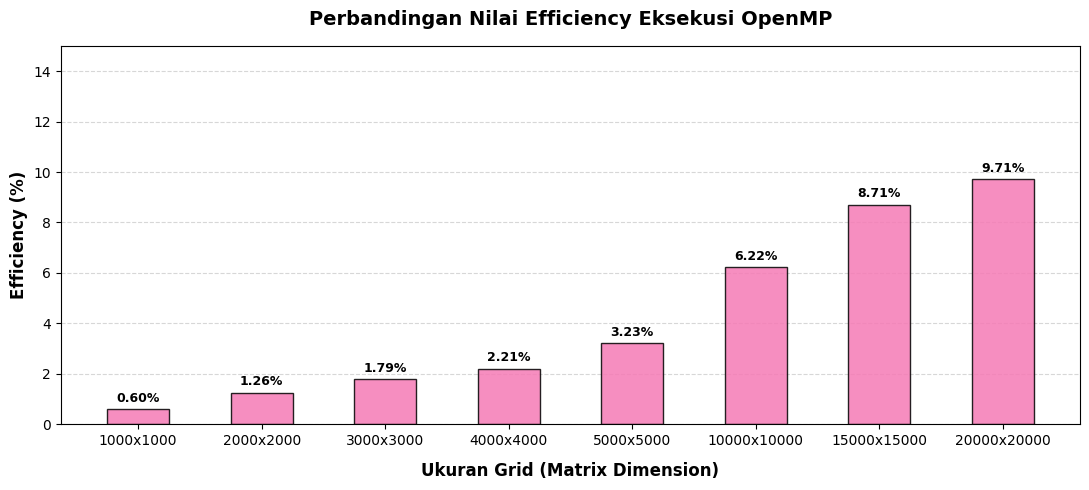

In [6]:
grid_sizes = ['1000x1000', '2000x2000', '3000x3000', '4000x4000', '5000x5000', '10000x10000', '15000x15000', '20000x20000']

seq_times = [0.0993, 0.4253, 0.9247, 1.8165, 3.0707, 16.3672, 37.0478, 57.2313]
omp_times = [0.5088, 1.0549, 1.6069, 2.5576, 2.9696, 8.2206, 13.2905, 18.4173]
cl_times  = [1.4793, 1.5213, 1.6205, 1.7614, 2.3175, 5.6704,  10.7635, 18.5031]

speedup_omp = [0.1951, 0.4032, 0.5754, 0.7102, 1.0340, 1.9910, 2.7875, 3.1074]
speedup_cl  = [0.0671, 0.2796, 0.5706, 1.0312, 1.3250, 2.8863, 3.4419, 3.0930]

efficiency_omp = [0.0060 * 100, 0.0126 * 100, 0.0179 * 100, 0.0221 * 100,
                  0.0323 * 100, 0.0622 * 100, 0.0871 * 100, 0.0971 * 100]

x = np.arange(len(grid_sizes))
width = 0.25

plt.figure(figsize=(12, 6))

bars_seq = plt.bar(x - width, seq_times, width, label='Sequential', color="#943A4C", edgecolor='black', alpha=0.85)
bars_omp = plt.bar(x, omp_times, width, label='OpenMP', color='#F57AB58C', edgecolor='black', alpha=0.85)
bars_cl  = plt.bar(x + width, cl_times, width, label='OpenCL', color='#D4A7FFB2', edgecolor='black', alpha=0.85)

plt.xlabel('Ukuran Grid (Matrix Dimension)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
plt.title('Perbandingan Waktu Eksekusi Antar Metode', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, grid_sizes, rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().set_axisbelow(True)
plt.legend(fontsize=11)

for bars in [bars_seq, bars_omp, bars_cl]:
    for i, bar in enumerate(bars):
        if i >= 5:
            height = bar.get_height()
            plt.annotate(f'{height:.2f}s',
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 3), textcoords="offset points",
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(grid_sizes, speedup_omp, marker='o', linewidth=2.5, markersize=8, label='OpenMP Speedup', color='#F57AB5', alpha=0.9)
plt.plot(grid_sizes, speedup_cl, marker='s', linewidth=2.5, markersize=8, label='OpenCL Speedup', color='#A77BFF', alpha=0.9)

plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Baseline (Sequential = 1x)')

plt.xlabel('Ukuran Grid (Matrix Dimension)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Speedup Factor (x Times Faster)', fontsize=12, fontweight='bold')
plt.title('Perbandingan Nilai Speedup Komputasi Paralel', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

for i, txt in enumerate(speedup_omp):
    plt.annotate(f'{txt:.2f}x', (grid_sizes[i], speedup_omp[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')
for i, txt in enumerate(speedup_cl):
    plt.annotate(f'{txt:.2f}x', (grid_sizes[i], speedup_cl[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
bars_eff = plt.bar(grid_sizes, efficiency_omp, color='#F57AB58C', width=0.5, edgecolor='black', alpha=0.85, label='OpenMP Efficiency')

plt.xlabel('Ukuran Grid (Matrix Dimension)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Efficiency (%)', fontsize=12, fontweight='bold')
plt.title('Perbandingan Nilai Efficiency Eksekusi OpenMP', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().set_axisbelow(True)

plt.ylim(0, max(15, max(efficiency_omp) + 3))

for bar in bars_eff:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()